# МОДЕЛИРОВАНИЕ СИСТЕМЫ РЁССЛЕРА ЧЕРЕЗ IMPROVED NEURAL ODE

В этом ноутбуке выбрана усиленная конфигурация модели для `ds_ressler`: более глубокая сеть, активация `SiLU`, более мягкий learning rate, регуляризация `AdamW`, gradient clipping, callback для лучшей модели и отдельная валидационная траектория.

In [ ]:
!pip install -q torchdiffeq torchinfo

In [ ]:

%matplotlib inline

import os
import copy
import time
import random
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from mpl_toolkits.mplot3d import Axes3D
from torchdiffeq import odeint_adjoint as odeint
from torchinfo import summary


## НАСТРОЙКИ ЭКСПЕРИМЕНТА

In [ ]:

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

batch_size = 64
batch_time = 30
data_size = 2500
niters = 5000
test_freq = 100
lr = 5e-4
weight_decay = 1e-5
grad_clip = 1.0
terminal_weight = 0.3
solver = "dopri5"

hidden_dims = (128, 128, 128, 64)
activation_name = "silu"

scheduler_patience = 5
min_lr = 1e-6
early_stopping_patience = 8
early_stopping_min_delta = 1e-4

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

print(f"Device: {device}")


Device: cpu


## ПАПКИ ДЛЯ АРТЕФАКТОВ

In [ ]:

os.makedirs("checkpoints", exist_ok=True)
os.makedirs("png_rossler_improved", exist_ok=True)
os.makedirs("docs", exist_ok=True)
os.makedirs("results", exist_ok=True)


## ПАРАМЕТРЫ СИСТЕМЫ РЕССЛЕРА

In [ ]:

a = 0.2
b = 0.2
c = 5.7


## НАЧАЛЬНЫЕ УСЛОВИЯ И ВРЕМЯ

In [ ]:

t = torch.linspace(0.0, 50.0, data_size).to(device)

train_y0_list = torch.tensor([
    [0.0,  1.0,  0.0],
    [0.2,  0.8,  0.1],
    [-0.3, 1.2,  0.0],
], dtype=torch.float32).to(device)

val_y0 = torch.tensor([[0.5, -0.5, 0.2]], dtype=torch.float32).to(device)
test_y0 = torch.tensor([[-0.7, 0.4, 0.3]], dtype=torch.float32).to(device)

print("Число обучающих траекторий:", len(train_y0_list))
print("Валидационное начальное условие:", val_y0)
print("Тестовое начальное условие:", test_y0)


Число обучающих траекторий: 3
Валидационное начальное условие: tensor([[ 0.5000, -0.5000,  0.2000]])
Тестовое начальное условие: tensor([[-0.7000,  0.4000,  0.3000]])


## ПРАВАЯ ЧАСТЬ ИСТИННОЙ СИСТЕМЫ

In [ ]:

class RosslerSystem(nn.Module):
    def forward(self, t, y):
        x = y[..., 0]
        y_coord = y[..., 1]
        z = y[..., 2]

        dx = -y_coord - z
        dy = x + a * y_coord
        dz = b + z * (x - c)

        return torch.stack([dx, dy, dz], dim=-1)


## ГЕНЕРАЦИЯ ЭТАЛОННЫХ ТРАЕКТОРИЙ

In [ ]:
def generate_trajectory(system, y0, t_grid, method="dopri5"):
    with torch.no_grad():
        traj = odeint(system, y0, t_grid, method=method)
    return traj


def generate_train_dataset(system, y0_list, t_grid):
    trajectories = []
    for y0 in y0_list:
        y0 = y0.view(1, 3)
        traj = generate_trajectory(system, y0, t_grid)
        trajectories.append(traj)
    return torch.stack(trajectories, dim=1)


true_system = RosslerSystem().to(device)
train_true_y = generate_train_dataset(true_system, train_y0_list, t)
val_true_y = generate_trajectory(true_system, val_y0, t)
test_true_y = generate_trajectory(true_system, test_y0, t)

print("train_true_y shape:", tuple(train_true_y.shape))
print("val_true_y shape:", tuple(val_true_y.shape))
print("test_true_y shape:", tuple(test_true_y.shape))


train_true_y shape: (2500, 3, 1, 3)
val_true_y shape: (2500, 1, 3)
test_true_y shape: (2500, 1, 3)


## ВЫБОРКА БАТЧЕЙ

In [ ]:

def get_batch(train_data, batch_size, batch_time, t_grid):
    num_traj = train_data.shape[1]

    start_idx = torch.from_numpy(
        np.random.choice(
            np.arange(train_data.shape[0] - batch_time, dtype=np.int64),
            batch_size,
            replace=True
        )
    ).long()

    traj_idx = torch.from_numpy(
        np.random.choice(
            np.arange(num_traj, dtype=np.int64),
            batch_size,
            replace=True
        )
    ).long()

    batch_y0 = train_data[start_idx, traj_idx]
    batch_t = t_grid[:batch_time]
    batch_y = torch.stack(
        [train_data[start_idx + i, traj_idx] for i in range(batch_time)],
        dim=0
    )

    return batch_y0.to(device), batch_t.to(device), batch_y.to(device)


## ВИЗУАЛИЗАЦИЯ С ТРАЕКТОРИЕЙ И СРЕЗОМ ПОЛЯ

In [ ]:

def visualize(true_y, pred_y, odefunc, itr, title_prefix="", z_slice=None, save_dir="png_rossler_improved"):
    true_np = true_y.detach().cpu().numpy()[:, 0, :]
    pred_np = pred_y.detach().cpu().numpy()[:, 0, :]
    t_np = t.detach().cpu().numpy()

    all_np = np.concatenate([true_np, pred_np], axis=0)
    x_min, x_max = all_np[:, 0].min(), all_np[:, 0].max()
    y_min, y_max = all_np[:, 1].min(), all_np[:, 1].max()
    z_min, z_max = all_np[:, 2].min(), all_np[:, 2].max()

    margin_x = 0.1 * (x_max - x_min + 1e-8)
    margin_y = 0.1 * (y_max - y_min + 1e-8)

    if z_slice is None:
        z_slice = float(np.median(true_np[:, 2]))

    fig = plt.figure(figsize=(16, 10), facecolor="white")

    ax_traj = fig.add_subplot(221, frameon=False)
    ax_traj.set_title(f"{title_prefix} | Координаты во времени")
    ax_traj.set_xlabel("t")
    ax_traj.set_ylabel("x, y, z")
    ax_traj.plot(t_np, true_np[:, 0], 'g-', label='x true')
    ax_traj.plot(t_np, true_np[:, 1], 'b-', label='y true')
    ax_traj.plot(t_np, true_np[:, 2], 'r-', label='z true')
    ax_traj.plot(t_np, pred_np[:, 0], 'g--', label='x pred')
    ax_traj.plot(t_np, pred_np[:, 1], 'b--', label='y pred')
    ax_traj.plot(t_np, pred_np[:, 2], 'r--', label='z pred')
    ax_traj.legend(loc='upper right')
    ax_traj.grid(True, alpha=0.3)

    ax_3d = fig.add_subplot(222, projection='3d')
    ax_3d.set_title(f"{title_prefix} | Траектория в пространстве состояний")
    ax_3d.set_xlabel("x")
    ax_3d.set_ylabel("y")
    ax_3d.set_zlabel("z")
    ax_3d.plot(true_np[:, 0], true_np[:, 1], true_np[:, 2], 'g-', label='Истина')
    ax_3d.plot(pred_np[:, 0], pred_np[:, 1], pred_np[:, 2], 'b--', label='Прогноз')
    ax_3d.legend()

    ax_phase = fig.add_subplot(223, frameon=False)
    ax_phase.set_title(f"{title_prefix} | Фазовая траектория (x, y)")
    ax_phase.set_xlabel("x")
    ax_phase.set_ylabel("y")
    ax_phase.plot(true_np[:, 0], true_np[:, 1], 'g-', label='Истина')
    ax_phase.plot(pred_np[:, 0], pred_np[:, 1], 'b--', label='Прогноз')
    ax_phase.set_xlim(x_min - margin_x, x_max + margin_x)
    ax_phase.set_ylim(y_min - margin_y, y_max + margin_y)
    ax_phase.legend()
    ax_phase.grid(True, alpha=0.3)

    ax_vec = fig.add_subplot(224, frameon=False)
    ax_vec.set_title(f"{title_prefix} | Срез изученного поля при z = {z_slice:.2f}")
    ax_vec.set_xlabel("x")
    ax_vec.set_ylabel("y")

    x_grid_vals = np.linspace(x_min - margin_x, x_max + margin_x, 25)
    y_grid_vals = np.linspace(y_min - margin_y, y_max + margin_y, 25)
    x_grid, y_grid = np.meshgrid(x_grid_vals, y_grid_vals)
    z_grid = np.ones_like(x_grid) * z_slice

    xyz_grid = np.stack([x_grid, y_grid, z_grid], axis=-1).reshape(-1, 3)

    with torch.no_grad():
        field = odefunc(
            0,
            torch.tensor(xyz_grid, dtype=torch.float32).to(device)
        ).detach().cpu().numpy()

    u = field[:, 0].reshape(x_grid.shape)
    v = field[:, 1].reshape(y_grid.shape)
    mag = np.sqrt(u**2 + v**2) + 1e-8
    u = u / mag
    v = v / mag

    ax_vec.streamplot(x_grid, y_grid, u, v, color="black", density=1.0)
    ax_vec.set_xlim(x_min - margin_x, x_max + margin_x)
    ax_vec.set_ylim(y_min - margin_y, y_max + margin_y)
    ax_vec.grid(True, alpha=0.3)

    fig.tight_layout()
    plt.savefig(f"{save_dir}/{itr:04d}.png", dpi=200, bbox_inches="tight")
    plt.show()


## ВСПОМОГАТЕЛЬНЫЕ КЛАССЫ

In [ ]:

class RunningAverageMeter:
    def __init__(self, momentum=0.99):
        self.momentum = momentum
        self.reset()

    def reset(self):
        self.val = None
        self.avg = 0.0

    def update(self, val):
        if self.val is None:
            self.avg = val
        else:
            self.avg = self.avg * self.momentum + val * (1 - self.momentum)
        self.val = val


class BestModelCheckpoint:
    def __init__(self, save_path, mode="min"):
        self.save_path = save_path
        self.mode = mode
        self.best_value = np.inf if mode == "min" else -np.inf
        self.best_iter = None

    def _is_improved(self, value):
        if self.mode == "min":
            return value < self.best_value
        return value > self.best_value

    def step(self, model, value, itr, config):
        if self._is_improved(value):
            self.best_value = float(value)
            self.best_iter = int(itr)
            checkpoint = {
                "model_state_dict": copy.deepcopy(model.state_dict()),
                "best_value": float(value),
                "best_iter": int(itr),
                "config": config,
                "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            }
            torch.save(checkpoint, self.save_path)
            return True
        return False


class EarlyStopping:
    def __init__(self, patience=250, min_delta=1e-5, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_value = np.inf if mode == "min" else -np.inf
        self.counter = 0

    def step(self, value):
        if self.mode == "min":
            improved = value < (self.best_value - self.min_delta)
        else:
            improved = value > (self.best_value + self.min_delta)

        if improved:
            self.best_value = value
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience


## МЕТРИКИ КАЧЕСТВА

In [ ]:

def trajectory_metrics(true_y, pred_y):
    true_cpu = true_y.detach().cpu().squeeze(1)
    pred_cpu = pred_y.detach().cpu().squeeze(1)

    err = pred_cpu - true_cpu
    abs_err = err.abs()
    sq_err = err.pow(2)

    mae = abs_err.mean().item()
    mse = sq_err.mean().item()
    rmse = float(np.sqrt(mse))
    max_ae = abs_err.max().item()

    coord_mae = abs_err.mean(dim=0)
    coord_rmse = torch.sqrt(sq_err.mean(dim=0))

    true_mean = true_cpu.mean(dim=0, keepdim=True)
    ss_res = ((true_cpu - pred_cpu) ** 2).sum(dim=0)
    ss_tot = ((true_cpu - true_mean) ** 2).sum(dim=0) + 1e-8
    r2 = 1.0 - ss_res / ss_tot

    return {
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
        "max_ae": max_ae,
        "x_mae": coord_mae[0].item(),
        "y_mae": coord_mae[1].item(),
        "z_mae": coord_mae[2].item(),
        "x_rmse": coord_rmse[0].item(),
        "y_rmse": coord_rmse[1].item(),
        "z_rmse": coord_rmse[2].item(),
        "x_r2": r2[0].item(),
        "y_r2": r2[1].item(),
        "z_r2": r2[2].item(),
    }


## НЕЙРОСЕТЕВАЯ ПРАВАЯ ЧАСТЬ

In [ ]:

def make_activation(name):
    name = name.lower()
    if name == "tanh":
        return nn.Tanh()
    if name == "relu":
        return nn.ReLU()
    if name == "silu":
        return nn.SiLU()
    if name == "elu":
        return nn.ELU()
    raise ValueError(f"Неизвестная активация: {name}")


class ODEFunc3D(nn.Module):
    def __init__(self, hidden_dims=(128, 128, 128, 64), activation="silu"):
        super().__init__()

        layers = []
        in_features = 3
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_features, hidden_dim))
            layers.append(make_activation(activation))
            in_features = hidden_dim

        layers.append(nn.Linear(in_features, 3))
        self.net = nn.Sequential(*layers)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.net.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.constant_(module.bias, 0.0)

    def forward(self, t, y):
        return self.net(y)


## СОЗДАНИЕ МОДЕЛИ И ОПТИМИЗАТОРА

In [ ]:

func = ODEFunc3D(hidden_dims=hidden_dims, activation=activation_name).to(device)
optimizer = optim.AdamW(func.parameters(), lr=lr, weight_decay=weight_decay)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=scheduler_patience,
    min_lr=min_lr
)

checkpoint = BestModelCheckpoint(
    save_path="checkpoints/best_model_rossler_improved.pt",
    mode="min"
)

early_stopping = EarlyStopping(
    patience=early_stopping_patience,
    min_delta=early_stopping_min_delta,
    mode="min"
)

time_meter = RunningAverageMeter(0.97)
loss_meter = RunningAverageMeter(0.97)

history = {
    "iter": [],
    "batch_mae": [],
    "val_mae": [],
    "lr": [],
}

config = {
    "hidden_dims": hidden_dims,
    "activation": activation_name,
    "lr": lr,
    "weight_decay": weight_decay,
    "batch_size": batch_size,
    "batch_time": batch_time,
    "niters": niters,
    "test_freq": test_freq,
    "grad_clip": grad_clip,
    "terminal_weight": terminal_weight,
    "solver": solver,
}

end = time.time()


## ОБУЧЕНИЕ

Iter 0001 | Batch MAE 0.931551 | Val MAE 2.262390 | LR 5.00e-04 | Time Avg 0.9768
Лучшая модель обновлена: iter = 1, val_mae = 2.262390


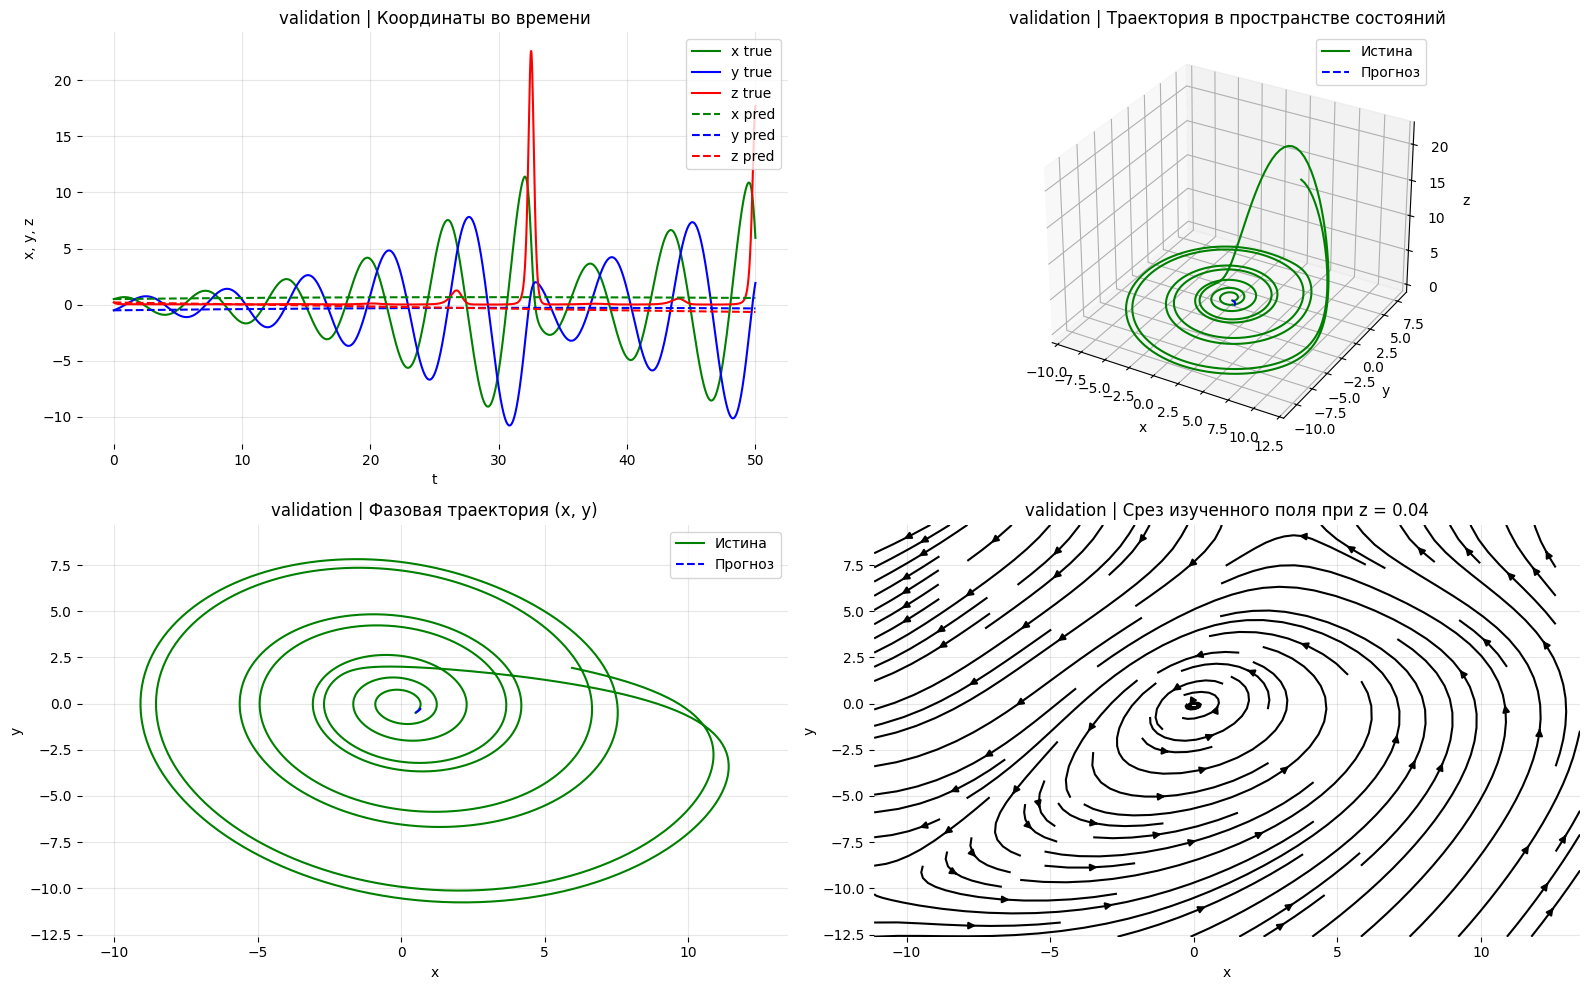

Iter 0100 | Batch MAE 0.153541 | Val MAE 1.274544 | LR 5.00e-04 | Time Avg 0.9878
Лучшая модель обновлена: iter = 100, val_mae = 1.274544


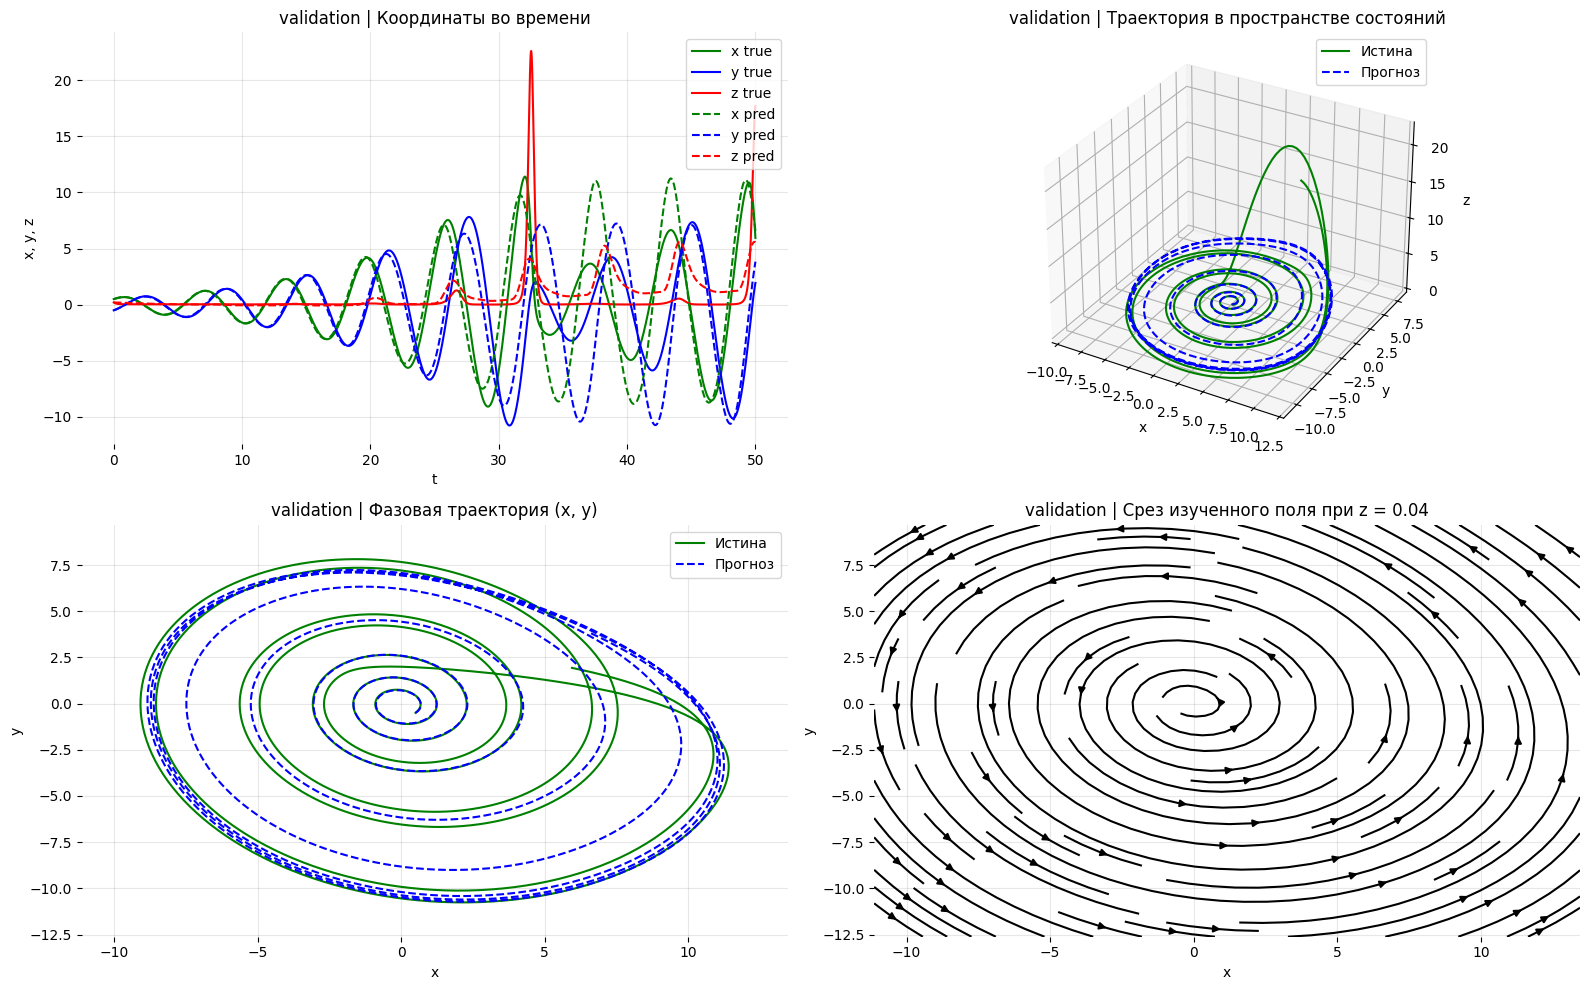

Iter 0200 | Batch MAE 0.148094 | Val MAE 0.961648 | LR 5.00e-04 | Time Avg 0.9668
Лучшая модель обновлена: iter = 200, val_mae = 0.961648


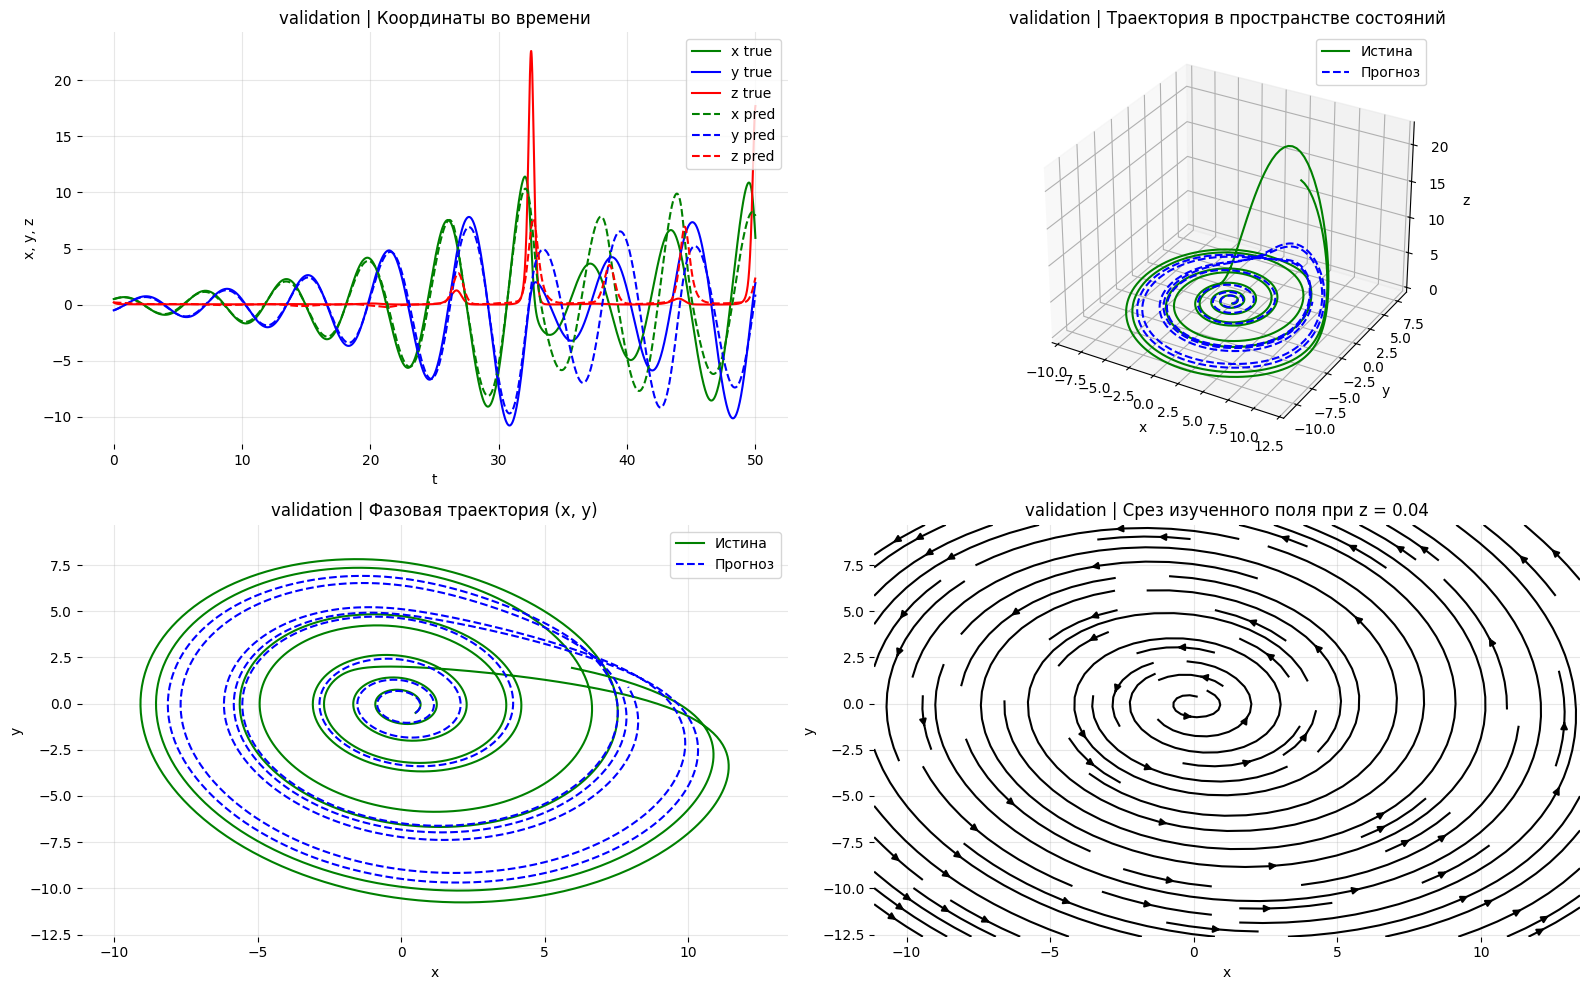

Iter 0300 | Batch MAE 0.037491 | Val MAE 0.495105 | LR 5.00e-04 | Time Avg 0.9622
Лучшая модель обновлена: iter = 300, val_mae = 0.495105


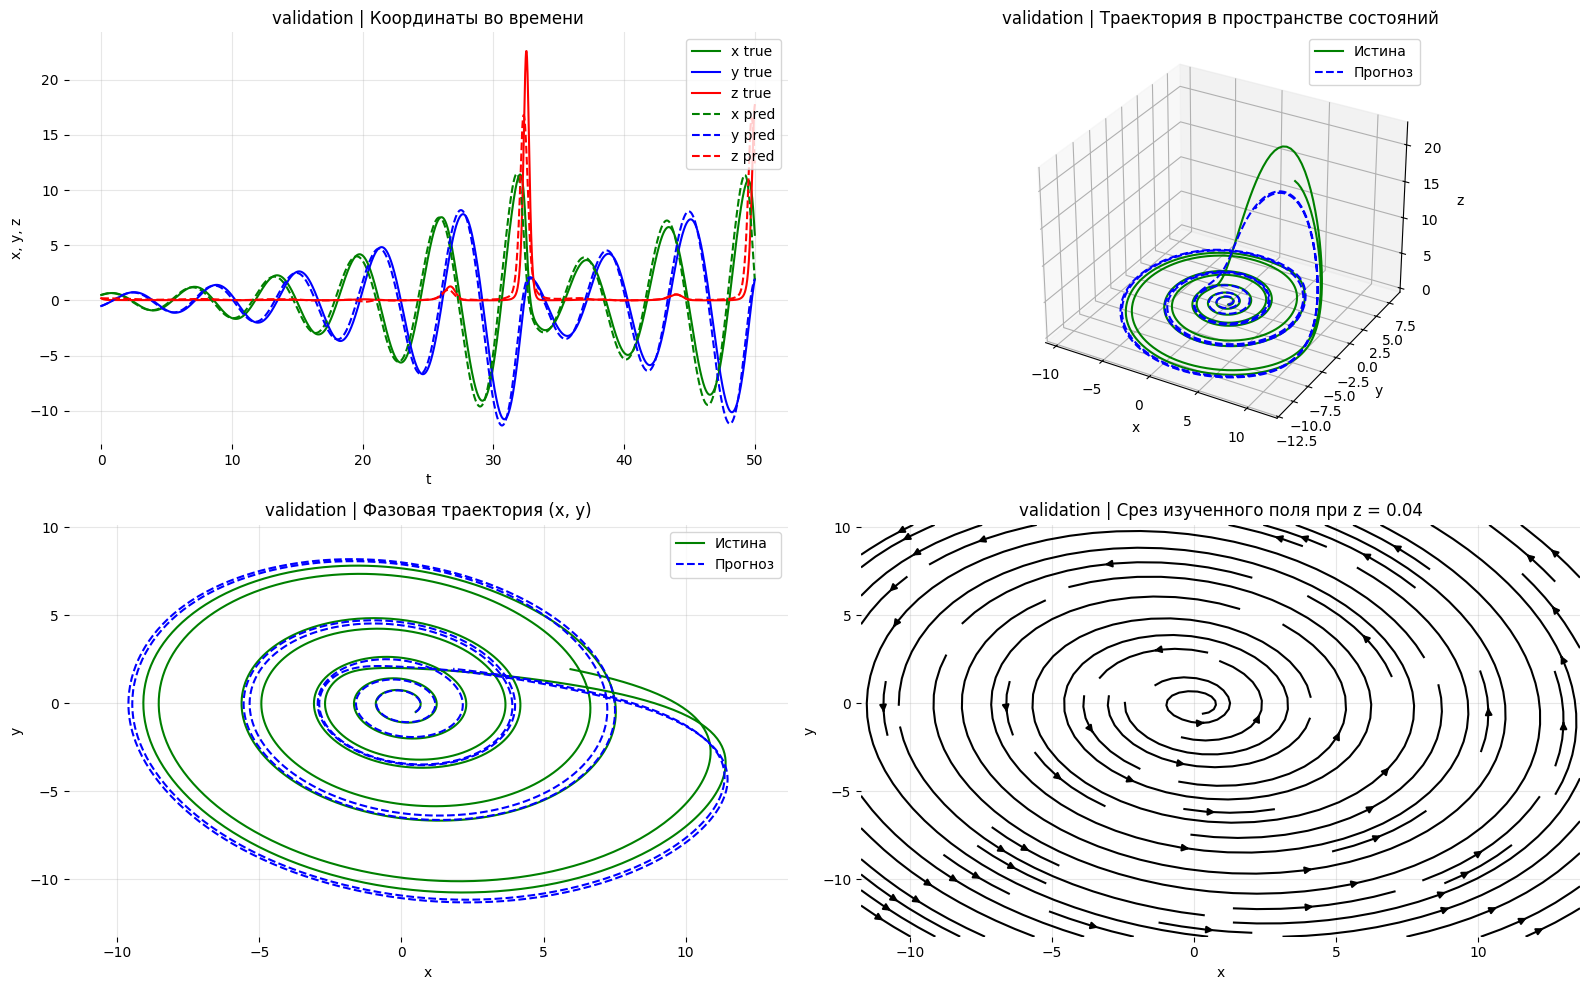

Iter 0400 | Batch MAE 0.023345 | Val MAE 0.332699 | LR 5.00e-04 | Time Avg 0.9929
Лучшая модель обновлена: iter = 400, val_mae = 0.332699


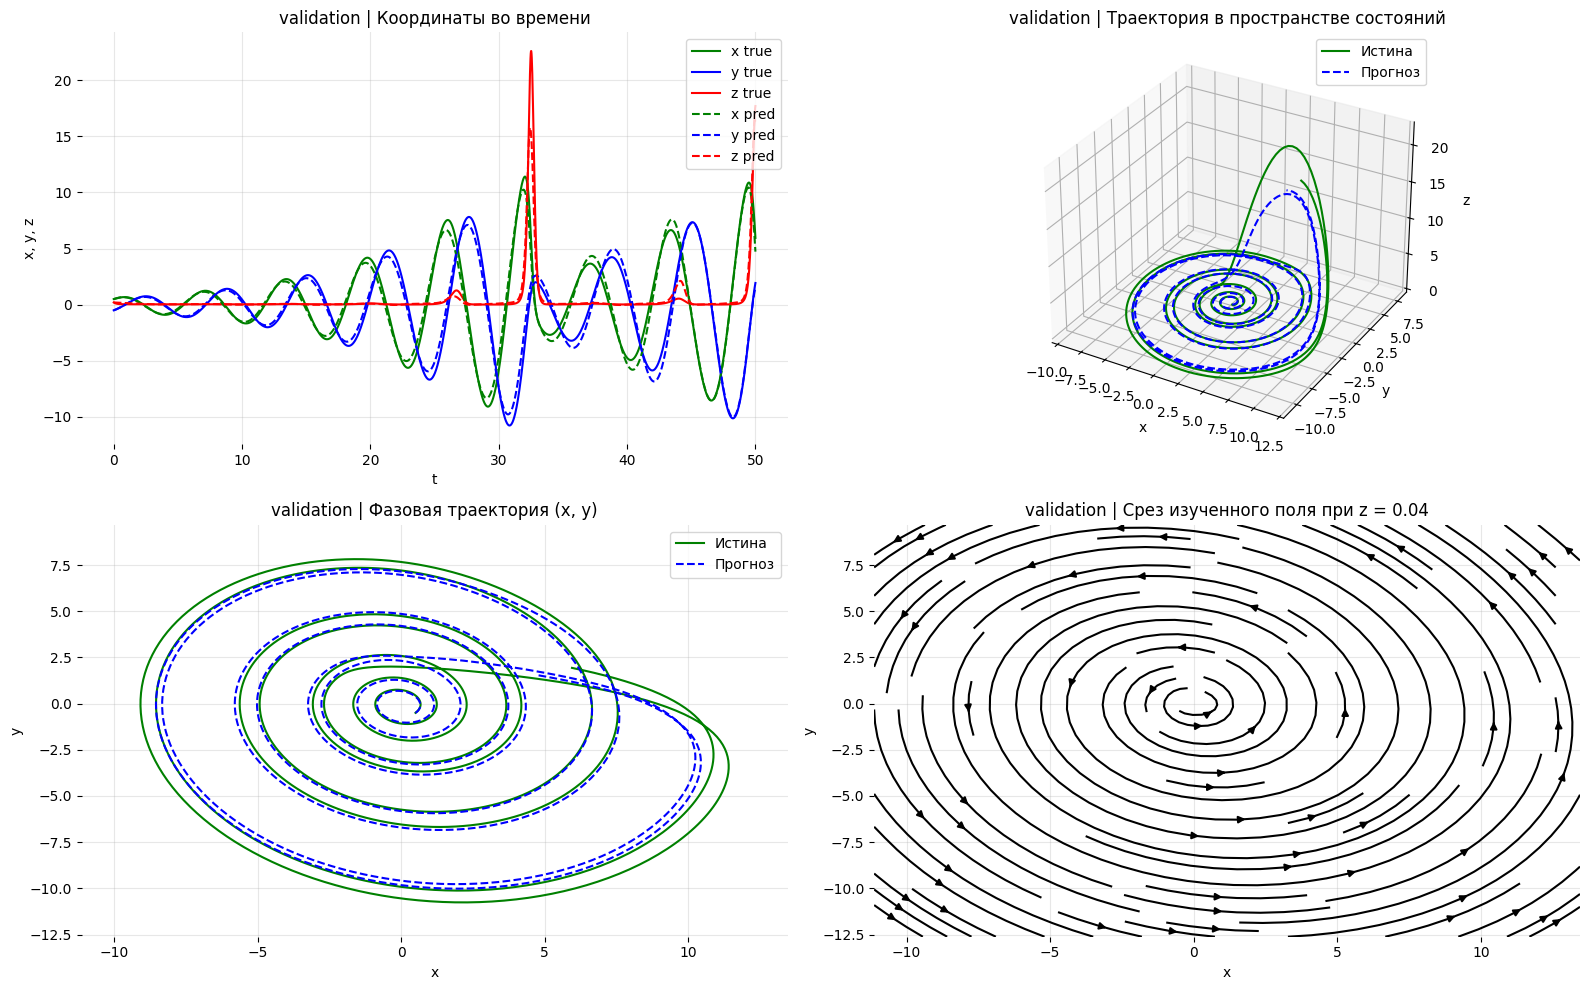

Iter 0500 | Batch MAE 0.021636 | Val MAE 0.802832 | LR 5.00e-04 | Time Avg 0.9602
Iter 0600 | Batch MAE 0.017368 | Val MAE 0.564568 | LR 5.00e-04 | Time Avg 0.9677
Iter 0700 | Batch MAE 0.016551 | Val MAE 0.772429 | LR 5.00e-04 | Time Avg 0.9734
Iter 0800 | Batch MAE 0.011253 | Val MAE 0.434223 | LR 5.00e-04 | Time Avg 1.0316
Iter 0900 | Batch MAE 0.012962 | Val MAE 0.319302 | LR 5.00e-04 | Time Avg 1.1002
Лучшая модель обновлена: iter = 900, val_mae = 0.319302


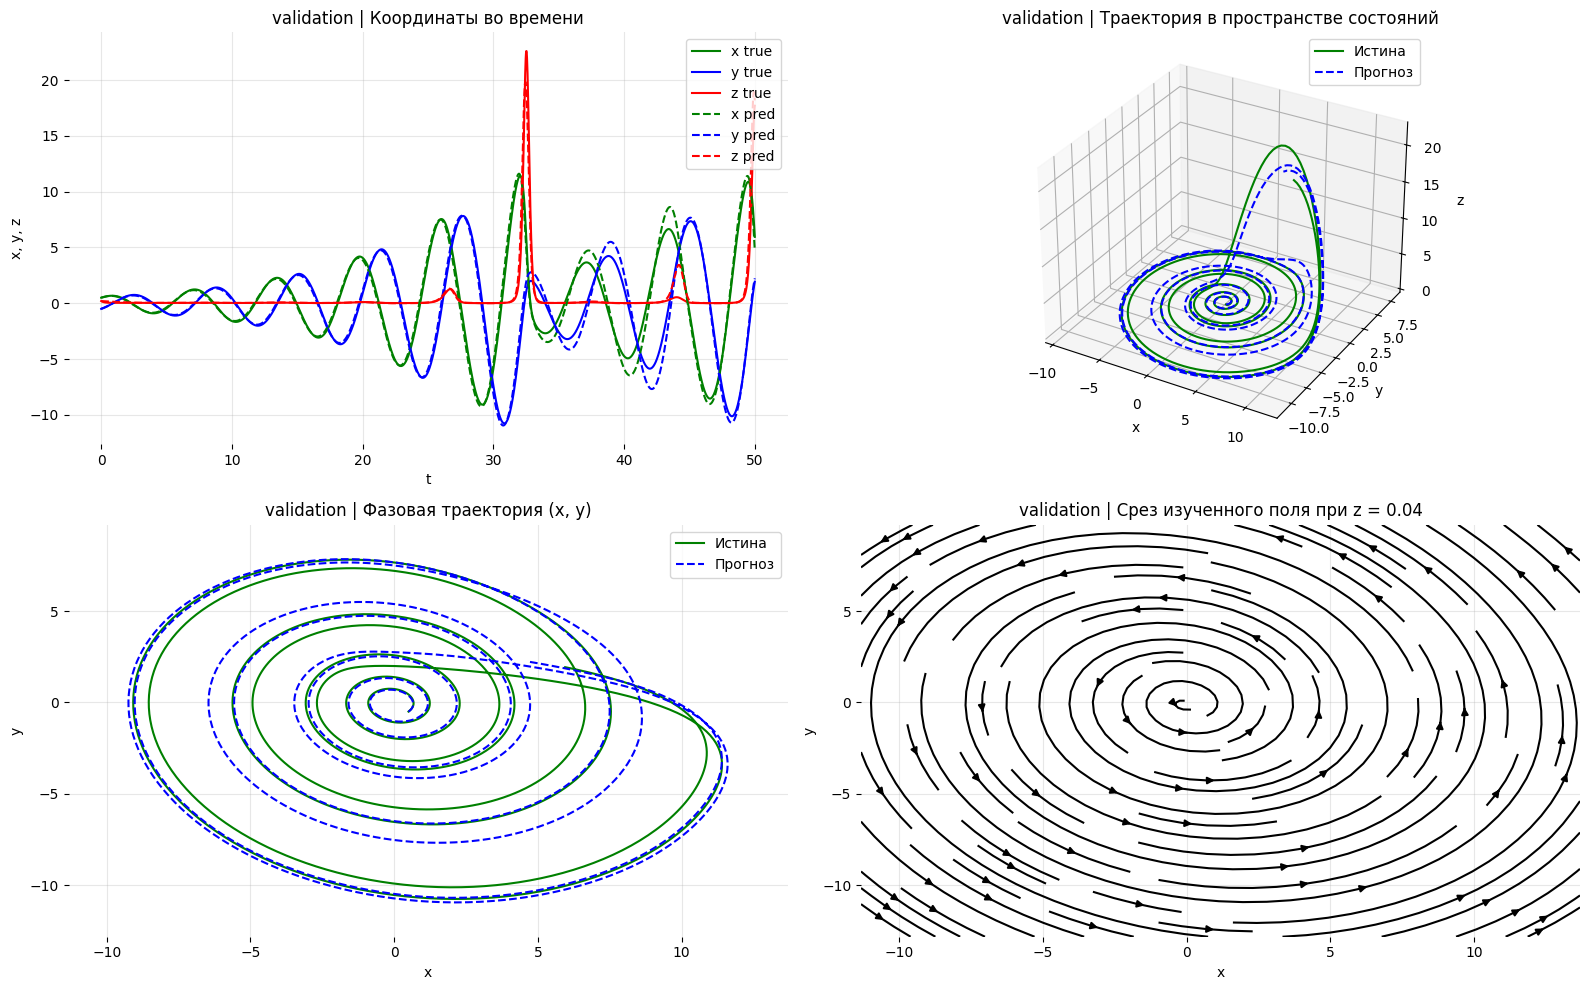

Iter 1000 | Batch MAE 0.017662 | Val MAE 0.792404 | LR 5.00e-04 | Time Avg 1.0810
Iter 1100 | Batch MAE 0.015869 | Val MAE 0.694041 | LR 5.00e-04 | Time Avg 1.0617
Iter 1200 | Batch MAE 0.012018 | Val MAE 0.206150 | LR 5.00e-04 | Time Avg 1.0822
Лучшая модель обновлена: iter = 1200, val_mae = 0.206150


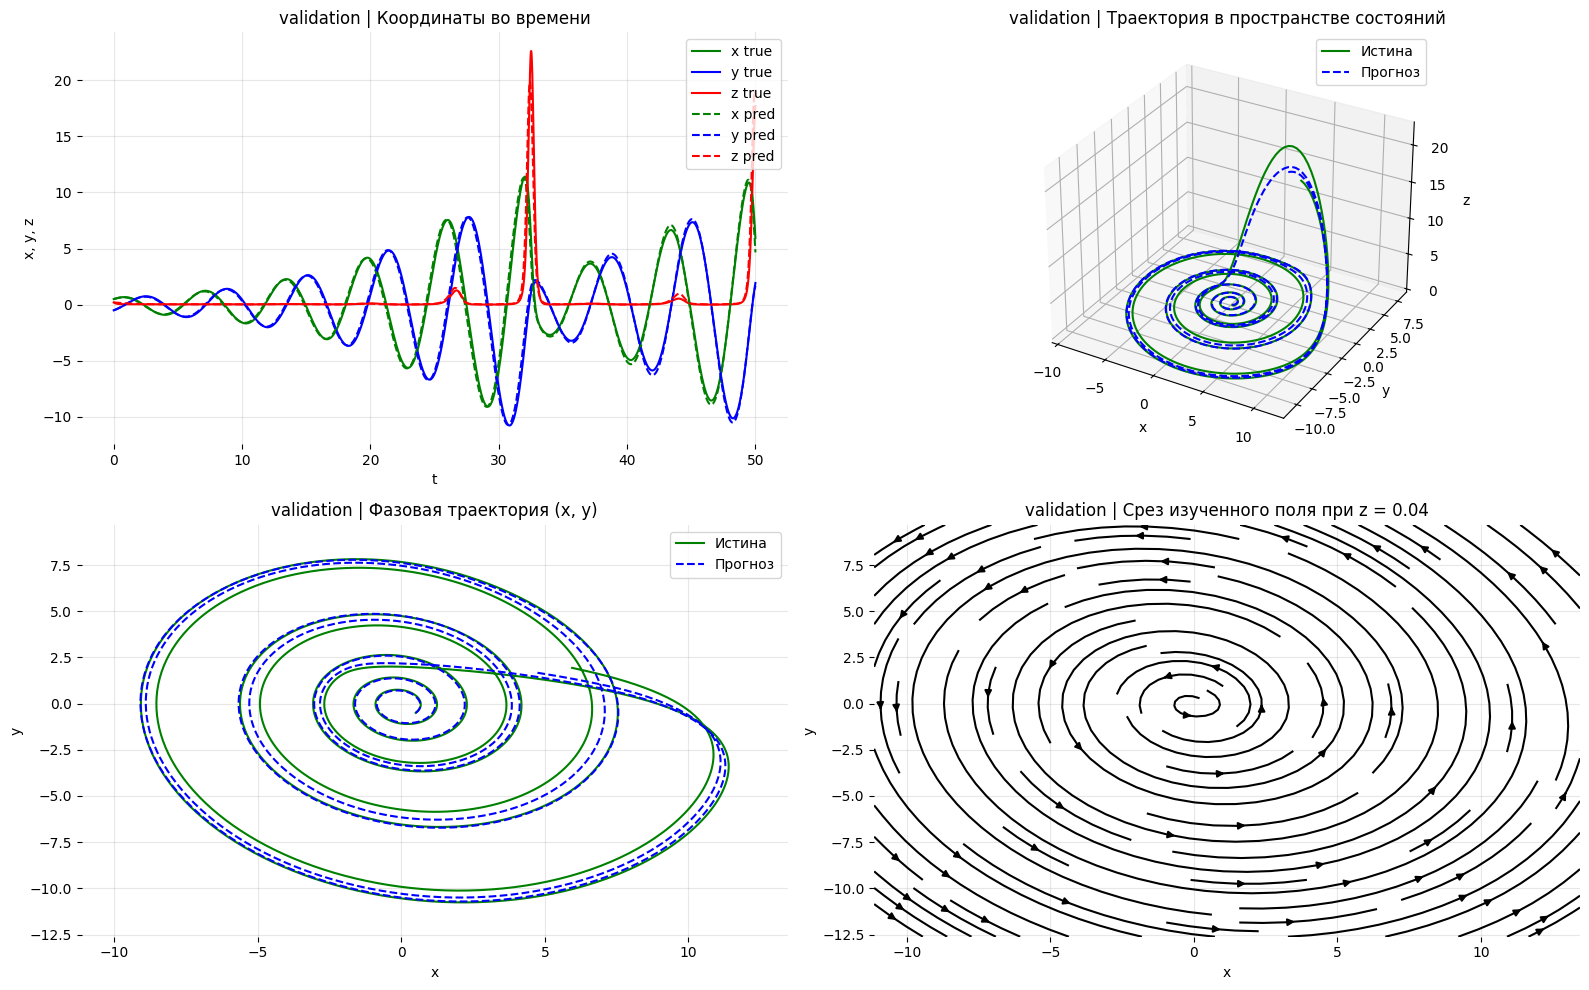

Iter 1300 | Batch MAE 0.012674 | Val MAE 0.234453 | LR 5.00e-04 | Time Avg 1.1022
Iter 1400 | Batch MAE 0.011164 | Val MAE 0.499573 | LR 5.00e-04 | Time Avg 1.0970
Iter 1500 | Batch MAE 0.006197 | Val MAE 0.201067 | LR 5.00e-04 | Time Avg 1.0867
Лучшая модель обновлена: iter = 1500, val_mae = 0.201067


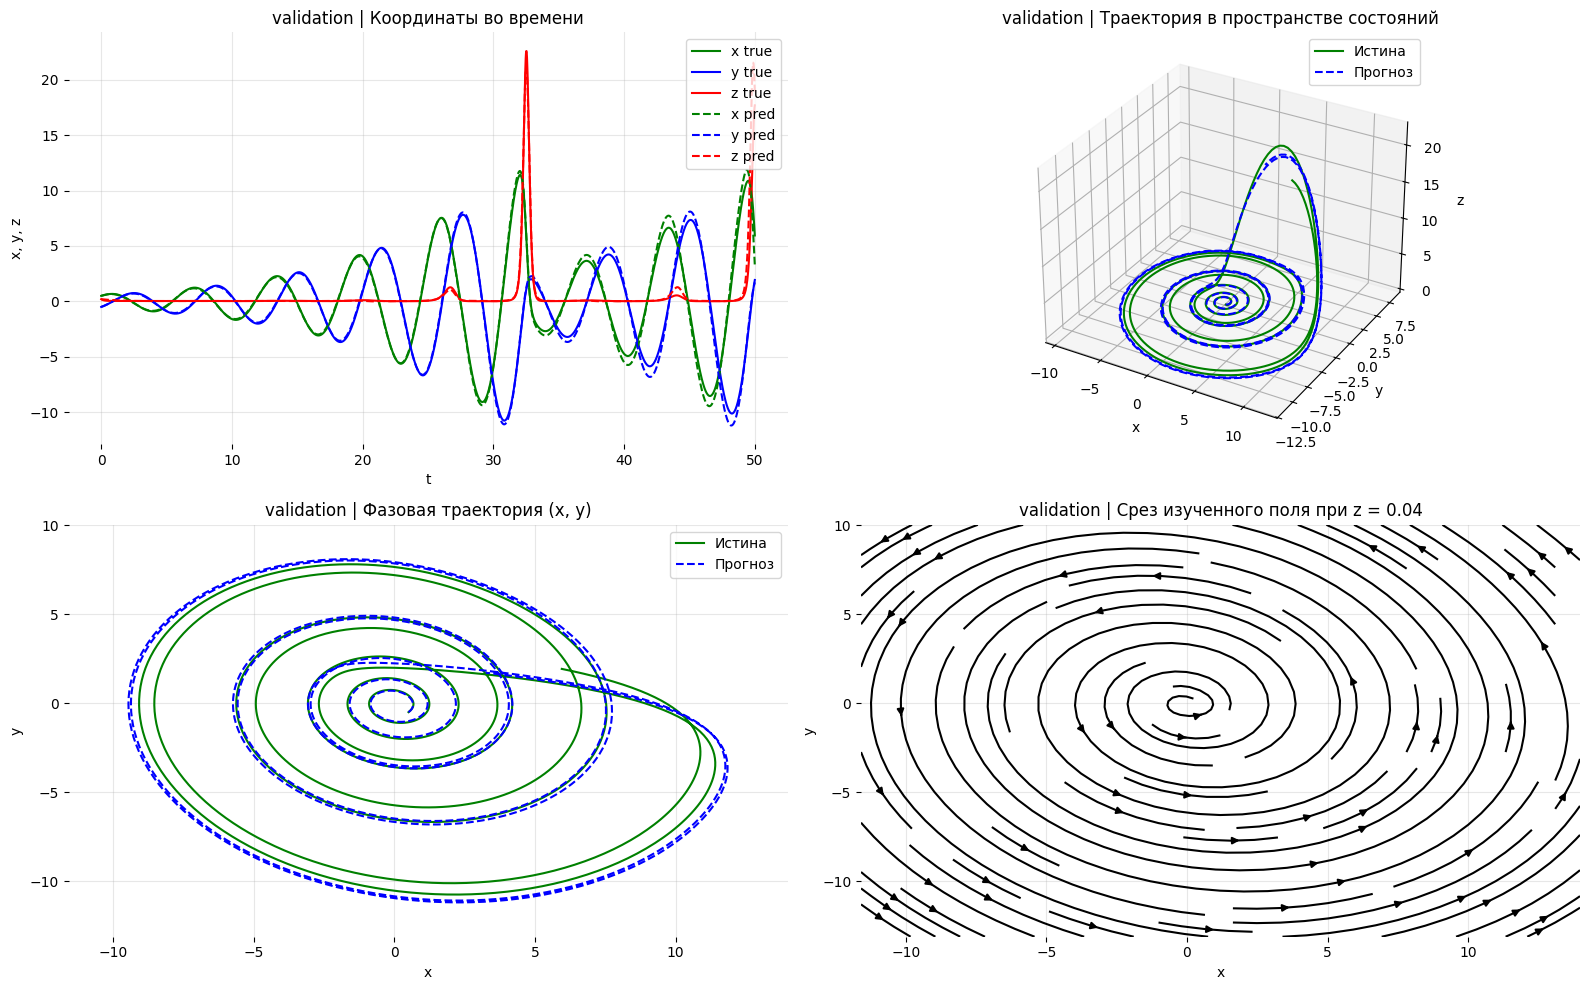

Iter 1600 | Batch MAE 0.012523 | Val MAE 0.518470 | LR 5.00e-04 | Time Avg 1.0691
Iter 1700 | Batch MAE 0.009604 | Val MAE 0.223595 | LR 5.00e-04 | Time Avg 1.0760
Iter 1800 | Batch MAE 0.007696 | Val MAE 0.101595 | LR 5.00e-04 | Time Avg 1.0961
Лучшая модель обновлена: iter = 1800, val_mae = 0.101595


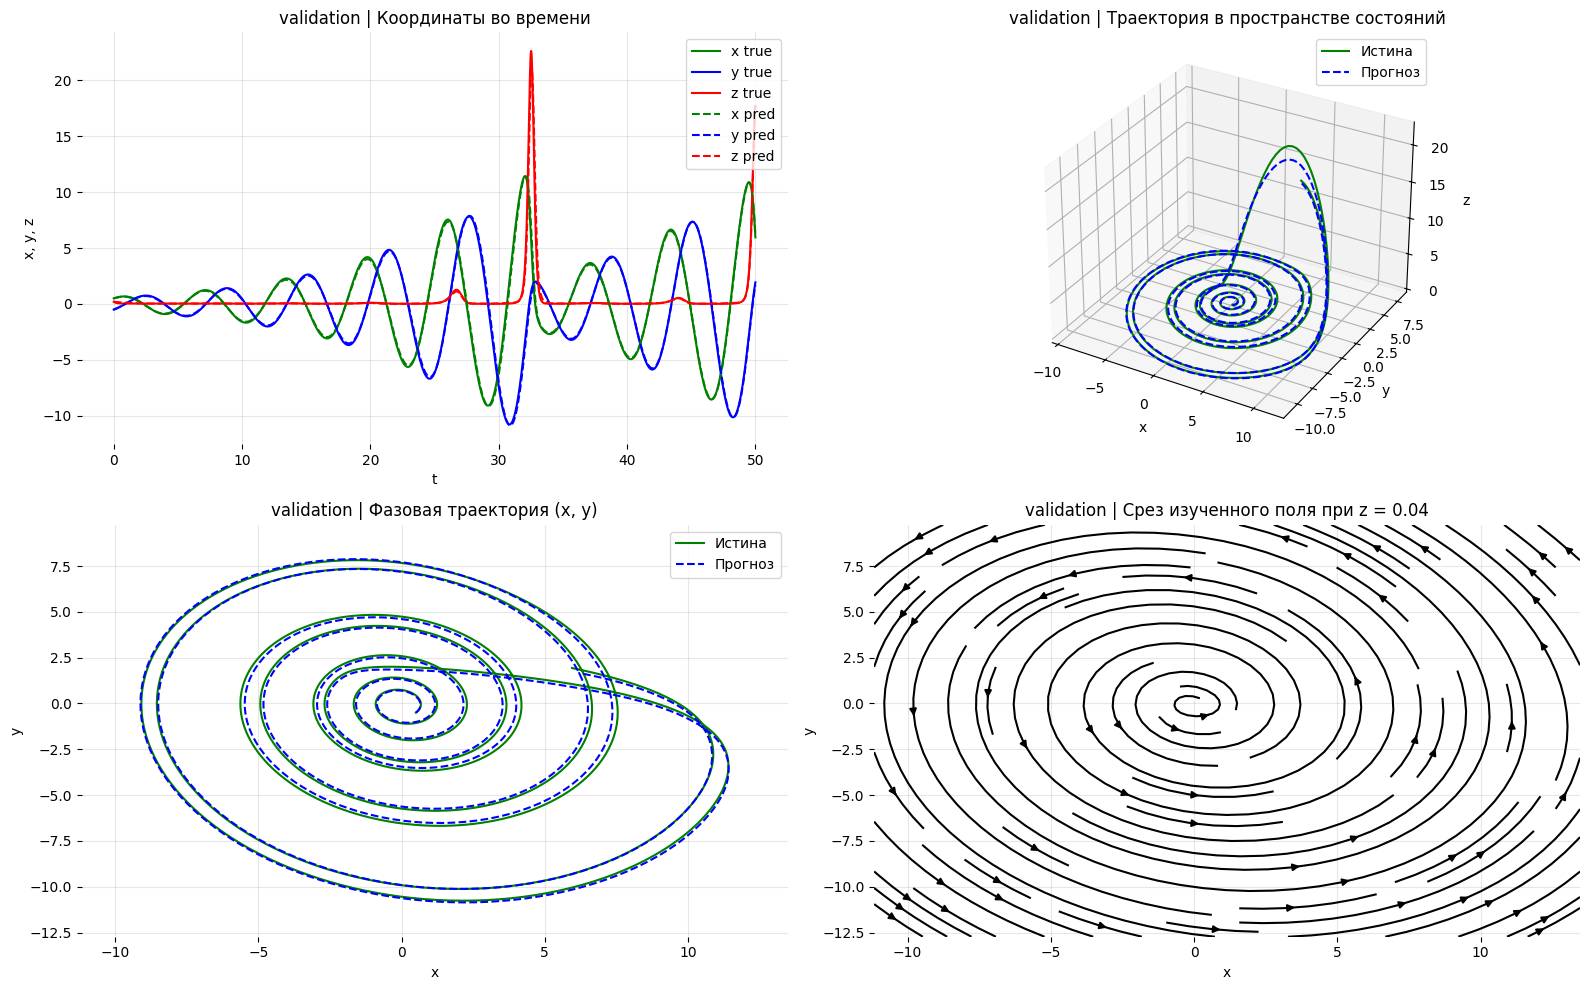

Iter 1900 | Batch MAE 0.007174 | Val MAE 0.102062 | LR 5.00e-04 | Time Avg 1.0585
Iter 2000 | Batch MAE 0.008530 | Val MAE 0.857570 | LR 5.00e-04 | Time Avg 1.0556
Iter 2100 | Batch MAE 0.013664 | Val MAE 0.435227 | LR 5.00e-04 | Time Avg 1.0579
Iter 2200 | Batch MAE 0.014302 | Val MAE 0.893097 | LR 5.00e-04 | Time Avg 1.0562
Iter 2300 | Batch MAE 0.010494 | Val MAE 0.080301 | LR 5.00e-04 | Time Avg 1.0922
Лучшая модель обновлена: iter = 2300, val_mae = 0.080301


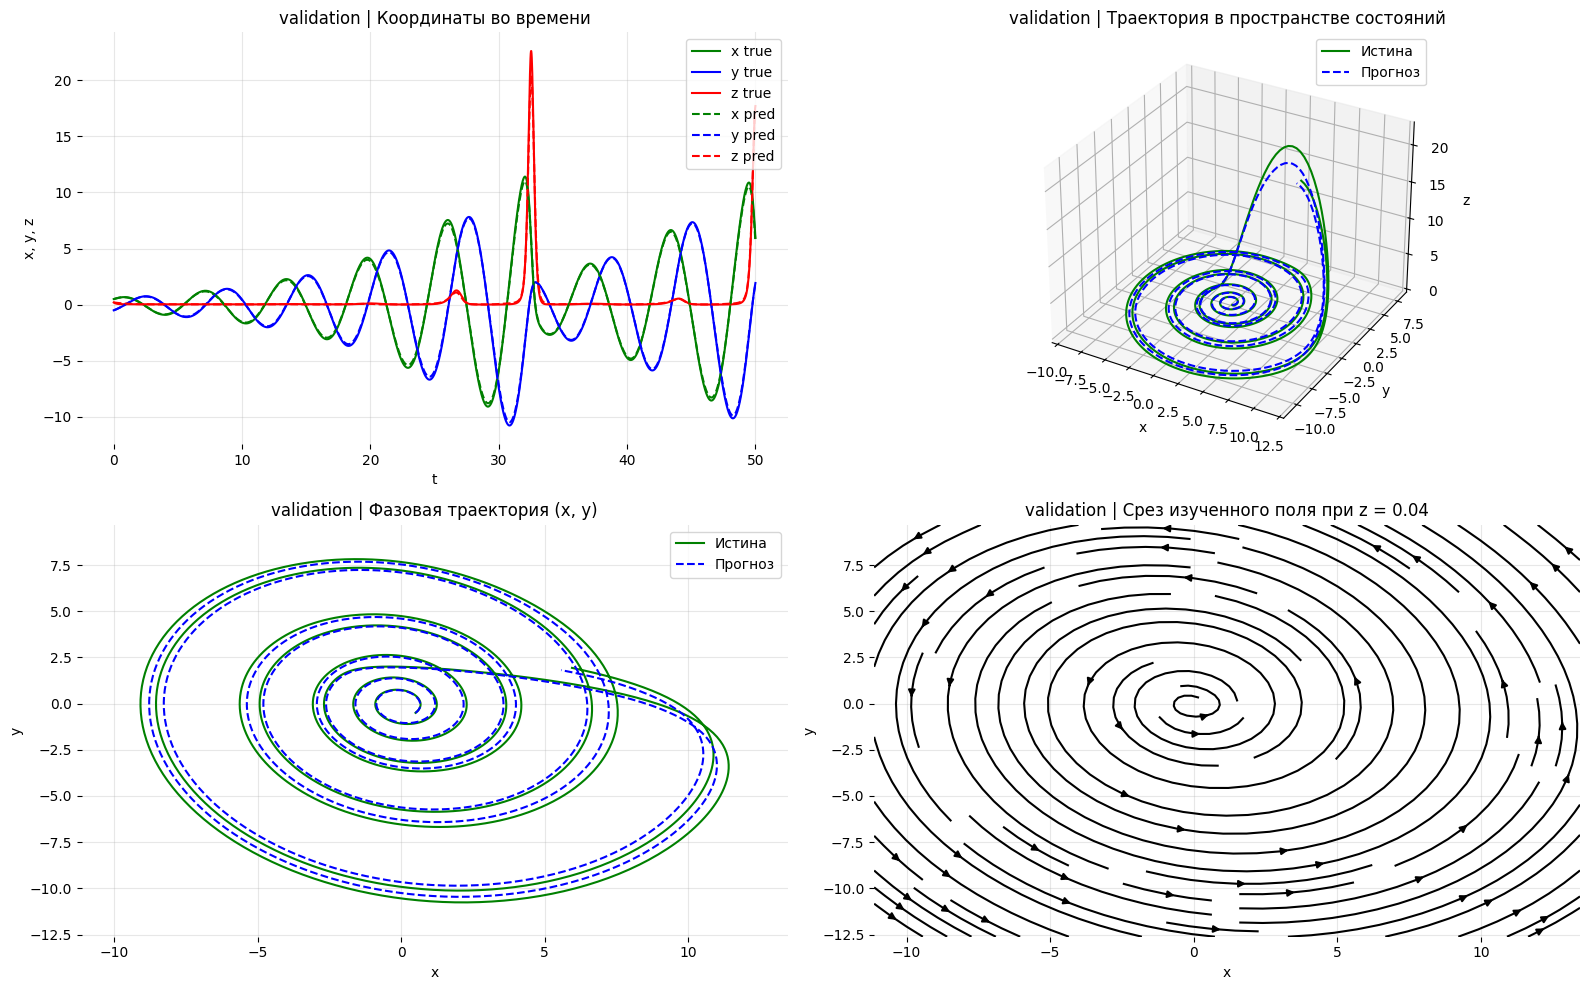

Iter 2400 | Batch MAE 0.011573 | Val MAE 0.619188 | LR 5.00e-04 | Time Avg 1.0563
Iter 2500 | Batch MAE 0.012277 | Val MAE 0.910457 | LR 5.00e-04 | Time Avg 1.0493
Iter 2600 | Batch MAE 0.008500 | Val MAE 0.209407 | LR 5.00e-04 | Time Avg 1.0605
Iter 2700 | Batch MAE 0.012769 | Val MAE 0.226089 | LR 5.00e-04 | Time Avg 1.0491
Iter 2800 | Batch MAE 0.011747 | Val MAE 0.371204 | LR 5.00e-04 | Time Avg 1.0334
Iter 2900 | Batch MAE 0.011711 | Val MAE 1.476069 | LR 2.50e-04 | Time Avg 1.0799
Iter 3000 | Batch MAE 0.006695 | Val MAE 0.443231 | LR 2.50e-04 | Time Avg 1.0689
Iter 3100 | Batch MAE 0.007367 | Val MAE 0.205540 | LR 2.50e-04 | Time Avg 1.0481
Ранняя остановка на итерации 3100


In [ ]:

for itr in range(1, niters + 1):
    func.train()
    optimizer.zero_grad()

    batch_y0, batch_t, batch_y = get_batch(
        train_data=train_true_y,
        batch_size=batch_size,
        batch_time=batch_time,
        t_grid=t
    )

    pred_y = odeint(func, batch_y0, batch_t, method=solver)

    loss_local = torch.mean(torch.abs(pred_y - batch_y))
    loss_terminal = torch.mean(torch.abs(pred_y[-1] - batch_y[-1]))
    loss = loss_local + terminal_weight * loss_terminal

    loss.backward()
    torch.nn.utils.clip_grad_norm_(func.parameters(), grad_clip)
    optimizer.step()

    time_meter.update(time.time() - end)
    loss_meter.update(loss.item())

    if itr % test_freq == 0 or itr == 1:
        func.eval()
        with torch.no_grad():
            val_pred_y = odeint(func, val_y0, t, method=solver)
            val_metrics = trajectory_metrics(val_true_y, val_pred_y)

        val_mae = val_metrics["mae"]
        scheduler.step(val_mae)

        history["iter"].append(itr)
        history["batch_mae"].append(loss_local.item())
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        print(
            f"Iter {itr:04d} | "
            f"Batch MAE {loss_local.item():.6f} | "
            f"Val MAE {val_mae:.6f} | "
            f"LR {optimizer.param_groups[0]['lr']:.2e} | "
            f"Time Avg {time_meter.avg:.4f}"
        )

        improved = checkpoint.step(func, val_mae, itr, config)
        if improved:
            print(f"Лучшая модель обновлена: iter = {itr}, val_mae = {val_mae:.6f}")
            with torch.no_grad():
                visualize(val_true_y, val_pred_y, func, itr, title_prefix="validation")

        if early_stopping.step(val_mae):
            print(f"Ранняя остановка на итерации {itr}")
            break

    end = time.time()


## КРИВЫЕ ОБУЧЕНИЯ

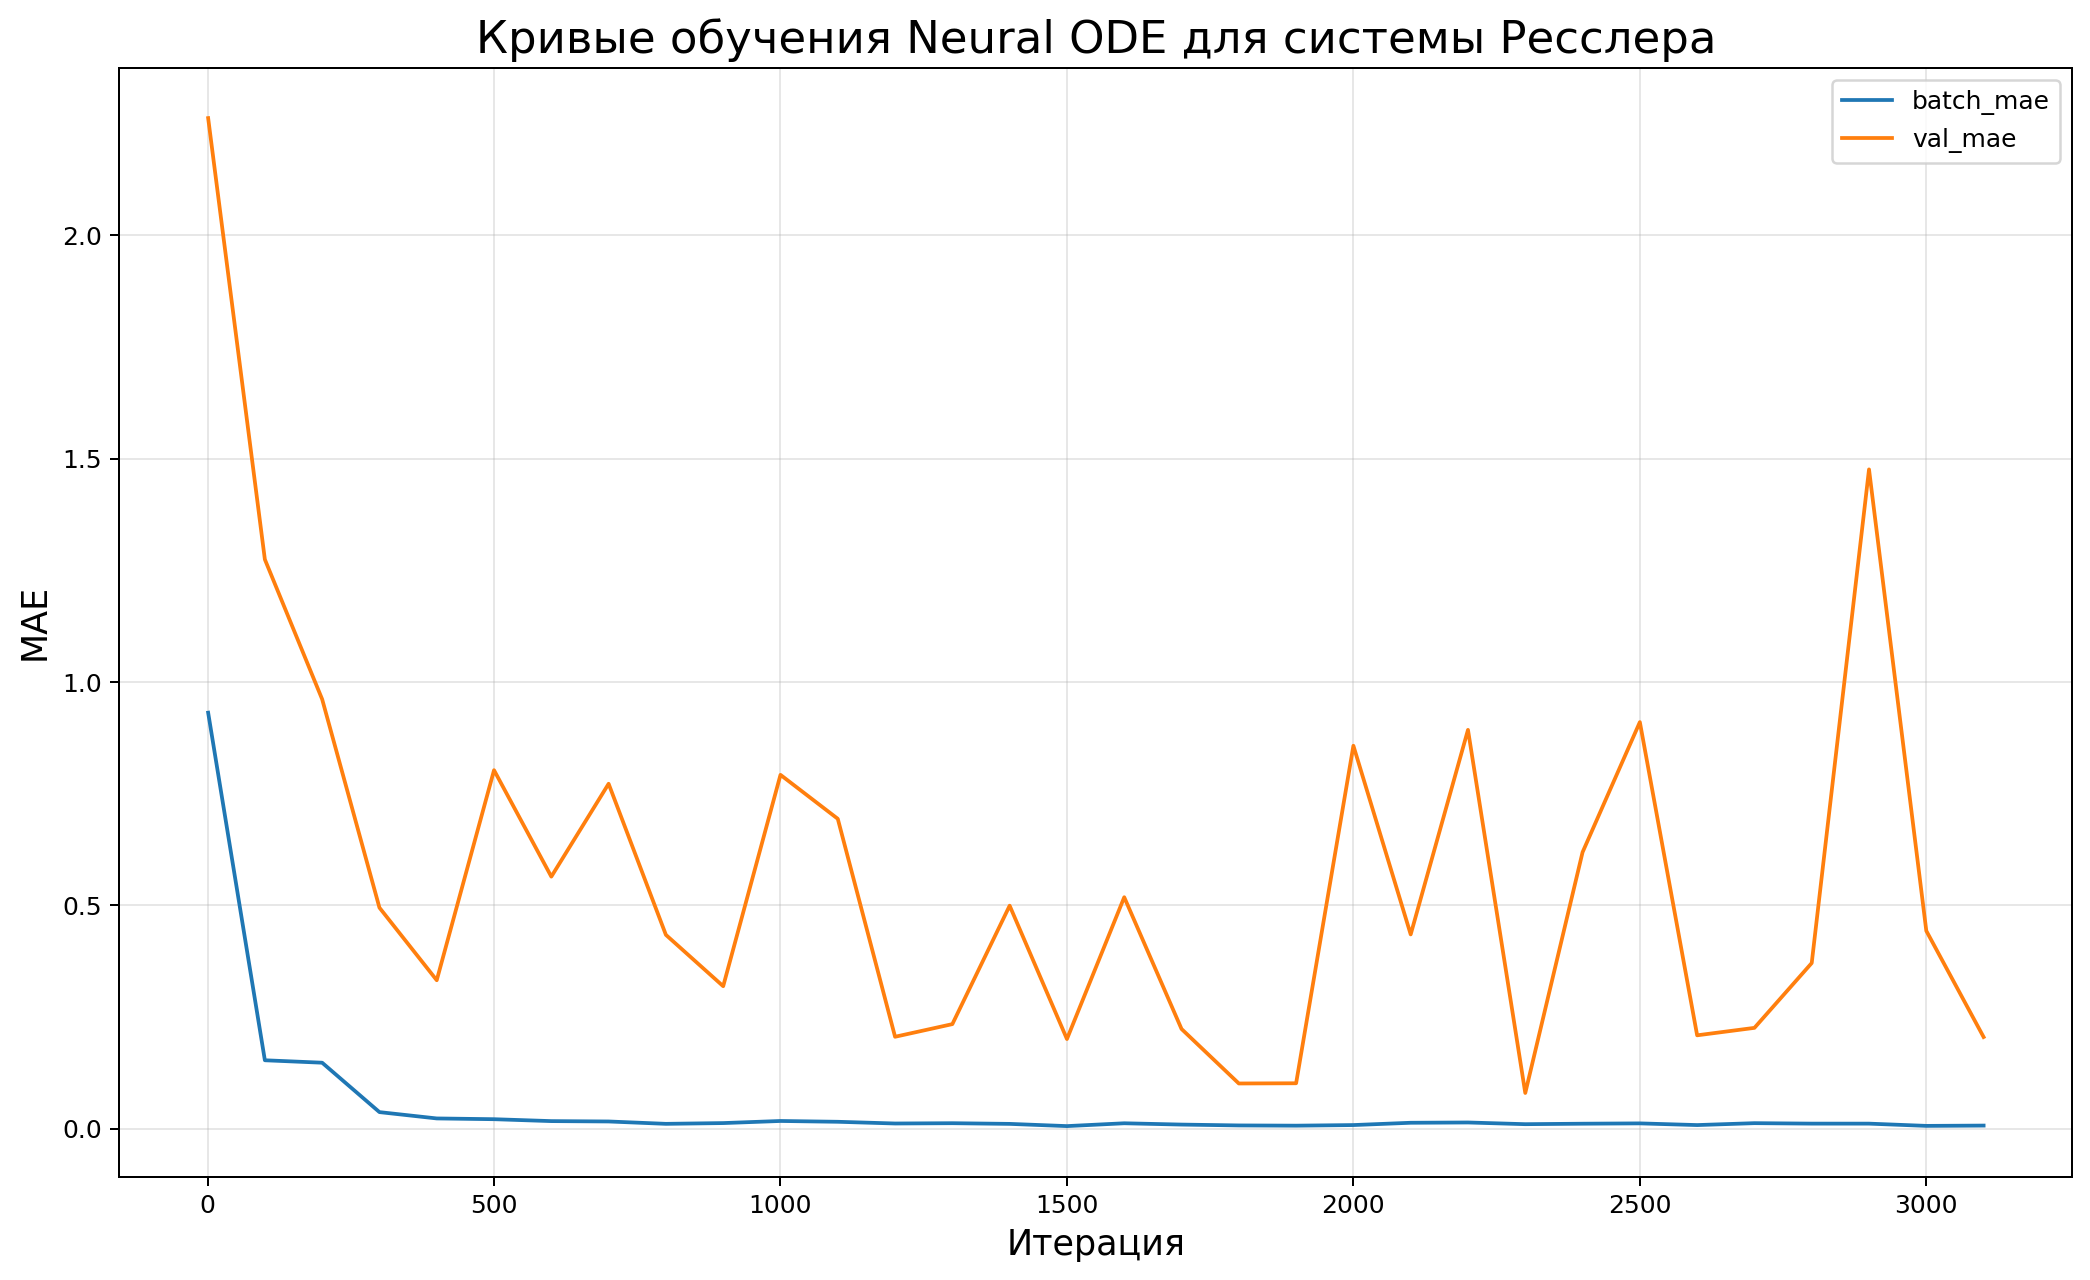

In [ ]:

plt.figure(figsize=(14, 8), dpi=180)
plt.plot(history["iter"], history["batch_mae"], label="batch_mae")
plt.plot(history["iter"], history["val_mae"], label="val_mae")
plt.xlabel("Итерация", fontsize=14)
plt.ylabel("MAE", fontsize=14)
plt.title("Кривые обучения Neural ODE для системы Ресслера", fontsize=18)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig("results/rossler_improved_learning_curves.png", dpi=200, bbox_inches="tight")
plt.show()


## ЗАГРУЗКА ЛУЧШЕЙ МОДЕЛИ

In [ ]:

best_checkpoint = torch.load("checkpoints/best_model_rossler_improved.pt", map_location=device)
func.load_state_dict(best_checkpoint["model_state_dict"])
func.eval()

print("Лучшая итерация:", best_checkpoint["best_iter"])
print("Лучший val_mae:", best_checkpoint["best_value"])
func


Лучшая итерация: 2300
Лучший val_mae: 0.08030115067958832


ODEFunc3D(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): SiLU()
    (8): Linear(in_features=64, out_features=3, bias=True)
  )
)

## МЕТРИКИ НА ВАЛИДАЦИИ И ТЕСТЕ

In [ ]:

with torch.no_grad():
    val_pred_y = odeint(func, val_y0, t, method=solver)
    test_pred_y = odeint(func, test_y0, t, method=solver)

val_metrics = trajectory_metrics(val_true_y, val_pred_y)
test_metrics = trajectory_metrics(test_true_y, test_pred_y)

print("Валидационные метрики:")
for key, value in val_metrics.items():
    print(f"{key}: {value:.6f}")

print("\nТестовые метрики:")
for key, value in test_metrics.items():
    print(f"{key}: {value:.6f}")

metrics_df = pd.DataFrame([
    {"split": "validation", **val_metrics},
    {"split": "test", **test_metrics},
])
metrics_df.to_csv("results/rossler_improved_metrics.csv", index=False, encoding="utf-8-sig")
metrics_df


Валидационные метрики:
mae: 0.080301
mse: 0.020300
rmse: 0.142480
max_ae: 2.196554
x_mae: 0.107520
y_mae: 0.087912
z_mae: 0.045471
x_rmse: 0.142029
y_rmse: 0.115993
z_rmse: 0.165151
x_r2: 0.998784
y_r2: 0.999116
z_r2: 0.994673

Тестовые метрики:
mae: 0.205867
mse: 0.184202
rmse: 0.429188
max_ae: 5.412699
x_mae: 0.254688
y_mae: 0.260374
z_mae: 0.102539
x_rmse: 0.416246
y_rmse: 0.423829
z_rmse: 0.446895
x_r2: 0.989910
y_r2: 0.988614
z_r2: 0.970431


,split,mae,mse,rmse,max_ae,x_mae,y_mae,z_mae,x_rmse,y_rmse,z_rmse,x_r2,y_r2,z_r2
0,validation,0.080301,0.020300,0.142480,2.196554,0.107520,0.087912,0.045471,0.142029,0.115993,0.165151,0.998784,0.999116,0.994673
1,test,0.205867,0.184202,0.429188,5.412699,0.254688,0.260374,0.102539,0.416246,0.423829,0.446895,0.989910,0.988614,0.970431


## ВИЗУАЛИЗАЦИЯ НА ВАЛИДАЦИИ

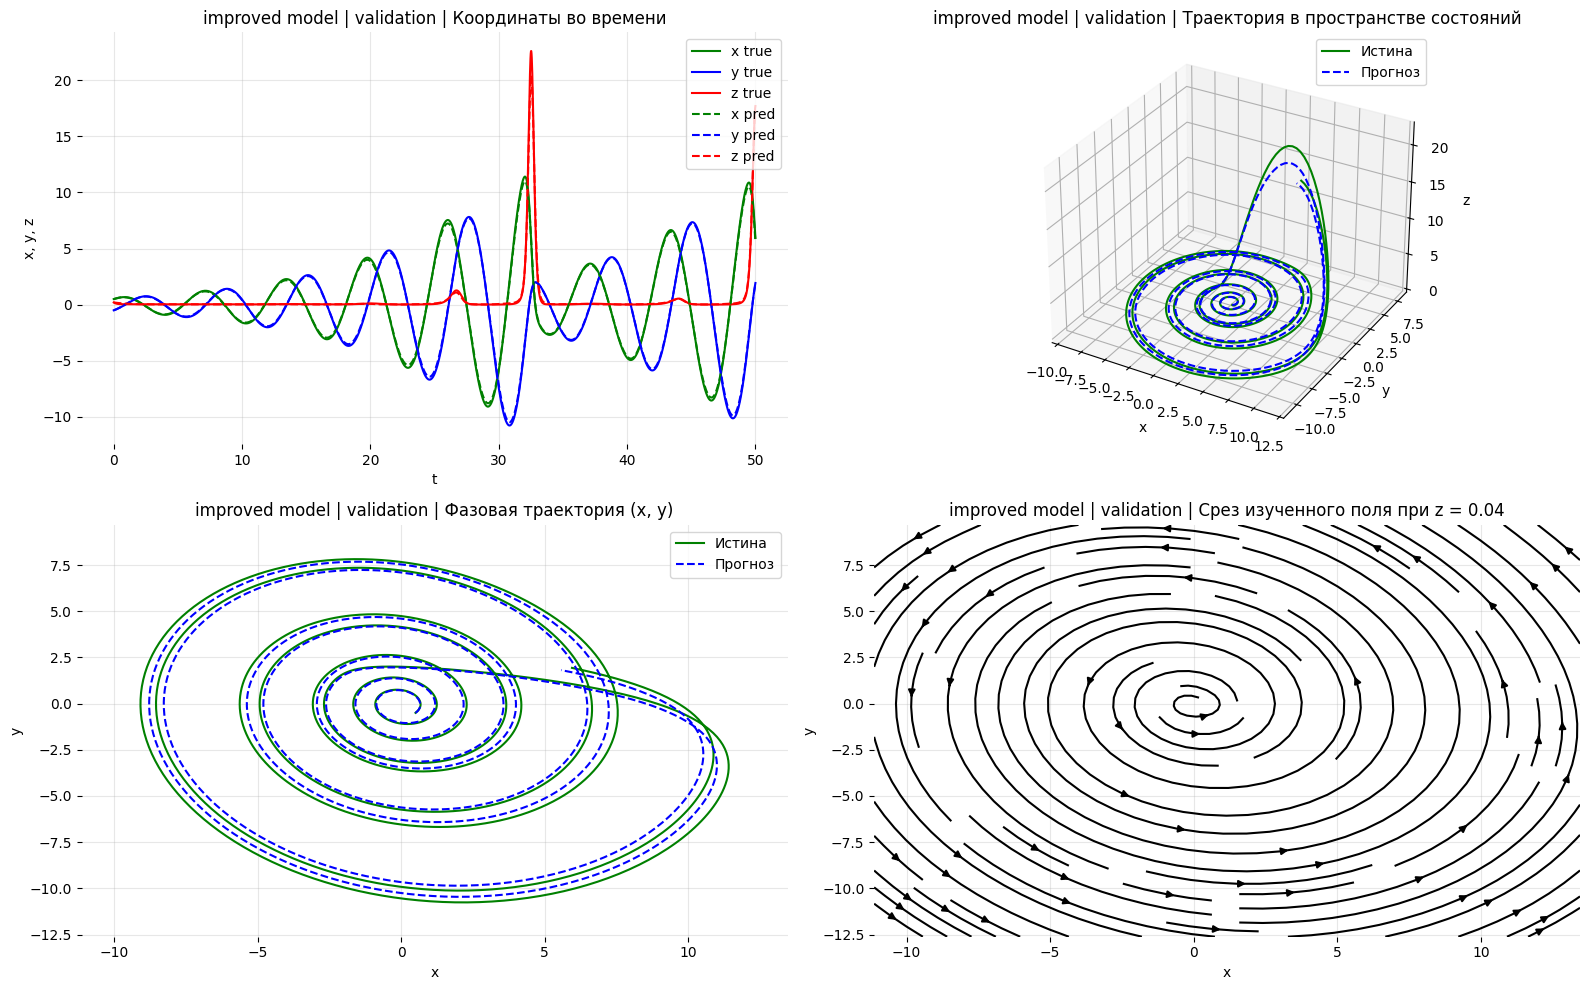

In [ ]:

with torch.no_grad():
    visualize(val_true_y, val_pred_y, func, 9001, title_prefix="improved model | validation")


## ВИЗУАЛИЗАЦИЯ НА ТЕСТЕ

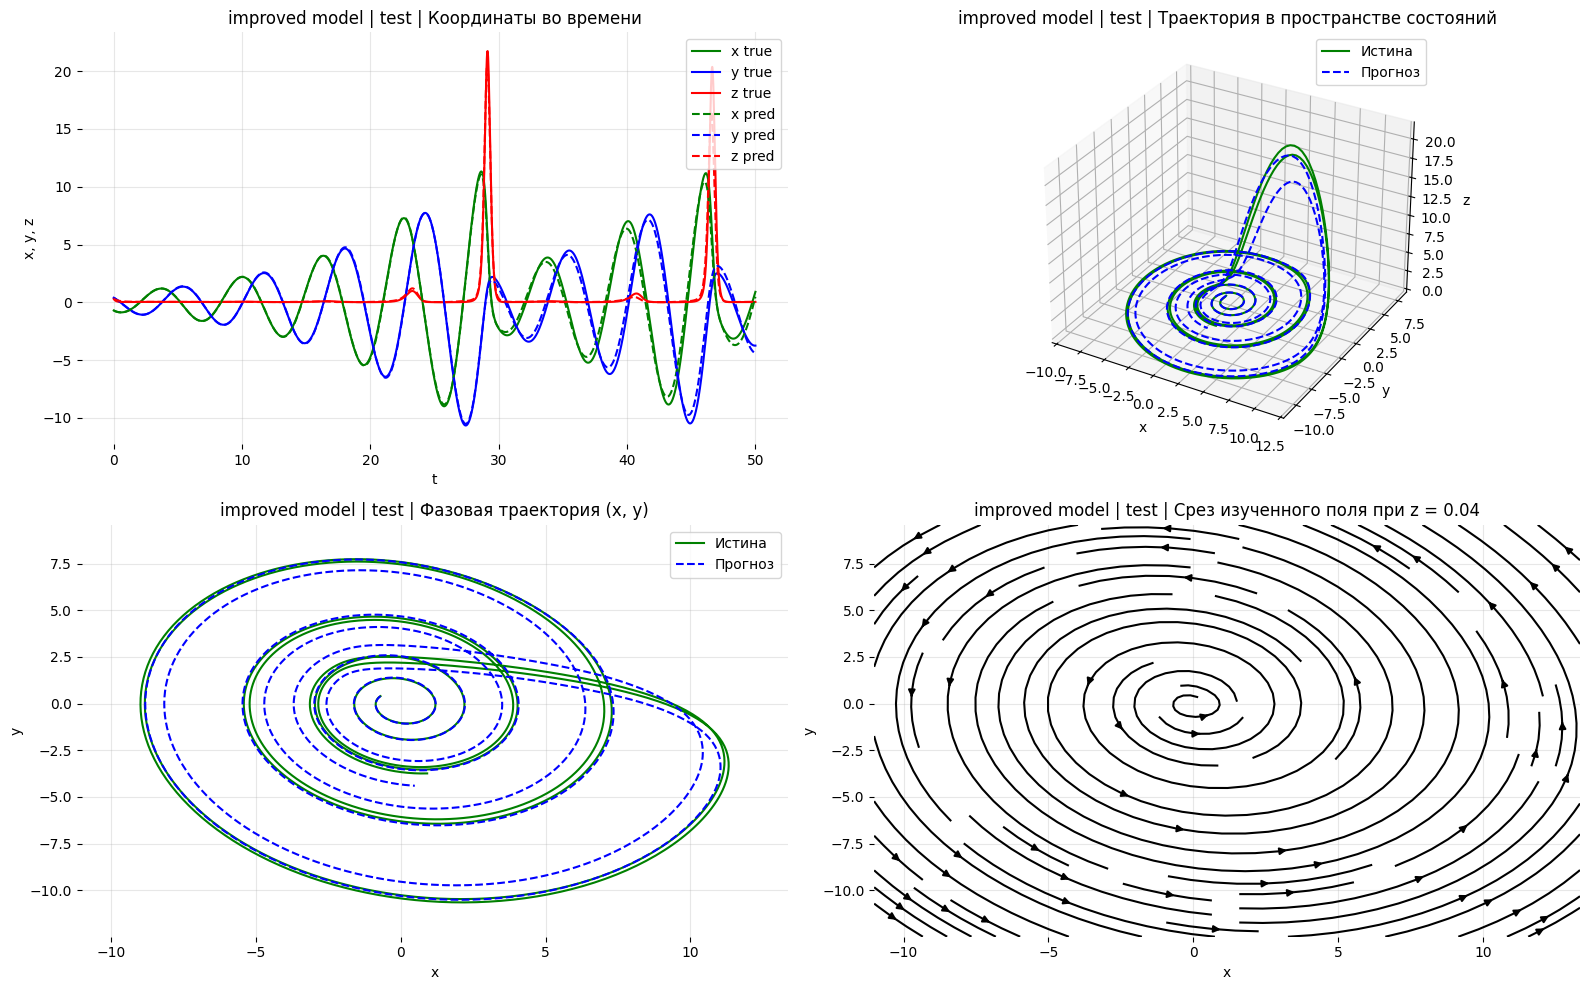

In [ ]:

with torch.no_grad():
    visualize(test_true_y, test_pred_y, func, 9002, title_prefix="improved model | test")


## SUMMARY МОДЕЛИ

In [ ]:

dummy_t = torch.tensor(0.0, dtype=torch.float32).to(device)
dummy_y = torch.randn(64, 3, dtype=torch.float32).to(device)

model_summary = summary(
    func,
    input_data=(dummy_t, dummy_y),
    col_names=("input_size", "output_size", "num_params", "trainable"),
    depth=5,
    verbose=1,
    device=str(device)
)

print(model_summary)

with open("docs/torchinfo_summary_rossler_improved.txt", "w", encoding="utf-8") as f:
    f.write(str(model_summary))


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ODEFunc3D                                --                        [64, 3]                   --                        True
├─Sequential: 1-1                        [64, 3]                   [64, 3]                   --                        True
│    └─Linear: 2-1                       [64, 3]                   [64, 128]                 512                       True
│    └─SiLU: 2-2                         [64, 128]                 [64, 128]                 --                        --
│    └─Linear: 2-3                       [64, 128]                 [64, 128]                 16,512                    True
│    └─SiLU: 2-4                         [64, 128]                 [64, 128]                 --                        --
│    └─Linear: 2-5                       [64, 128]                 [64, 128]                 16,512                    True
│    └─

## СОХРАНЕНИЕ ТЕКСТОВОГО ЛОГА

In [ ]:

log_text = f"""Improved Neural ODE Rossler Experiment Log
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Device: {device}

Rossler parameters:
a = {a}
b = {b}
c = {c}

Training parameters:
batch_size = {batch_size}
batch_time = {batch_time}
data_size = {data_size}
niters = {niters}
test_freq = {test_freq}
lr = {lr}
weight_decay = {weight_decay}
grad_clip = {grad_clip}
terminal_weight = {terminal_weight}
solver = {solver}

Model:
hidden_dims = {hidden_dims}
activation = {activation_name}

Best checkpoint:
iter = {best_checkpoint['best_iter']}
val_mae = {best_checkpoint['best_value']:.6f}

Validation metrics:
{val_metrics}

Test metrics:
{test_metrics}
"""

with open("results/rossler_improved_log.txt", "w", encoding="utf-8") as f:
    f.write(log_text)

print("Файл results/rossler_improved_log.txt сохранён")


Файл results/rossler_improved_log.txt сохранён
